In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('../../Data/syntheticData.csv', encoding ='latin-1')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   batch_id           6000 non-null   str    
 1   carbon_pct         6000 non-null   float64
 2   manganese_pct      6000 non-null   float64
 3   furnace_temp_C     6000 non-null   float64
 4   rolling_speed_mps  6000 non-null   float64
 5   cooling_rate_Cps   6000 non-null   float64
 6   defect             6000 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 369.3 KB


In [18]:
df.describe()

,carbon_pct,manganese_pct,furnace_temp_C,rolling_speed_mps,cooling_rate_Cps,defect
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,0.399650,0.897932,1601.437600,19.970430,14.971905,0.264667
std,0.119741,0.299666,54.892396,5.926212,5.876765,0.441192
min,0.050000,0.100000,1450.000000,5.000000,2.000000,0.000000
25%,0.320000,0.695750,1563.800000,15.810000,10.860000,0.000000
50%,0.400000,0.894000,1601.750000,19.950000,15.010000,0.000000
75%,0.479000,1.101000,1638.900000,24.050000,19.000000,1.000000
max,0.871000,1.959000,1750.000000,40.000000,37.150000,1.000000


In [19]:
df.isnull().sum()

batch_id             0
carbon_pct           0
manganese_pct        0
furnace_temp_C       0
rolling_speed_mps    0
cooling_rate_Cps     0
defect               0
dtype: int64

In [20]:
print("CHECK 1: Shape & class balance")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(df["defect"].value_counts(normalize=True).round(3))
print("Expect: defect rate roughly 0.20-0.26\n")

CHECK 1: Shape & class balance
Rows: 6000, Columns: 7
defect
0    0.735
1    0.265
Name: proportion, dtype: float64
Expect: defect rate roughly 0.20-0.26



In [21]:
features = ["carbon_pct", "manganese_pct", "furnace_temp_C", "rolling_speed_mps", "cooling_rate_Cps"]

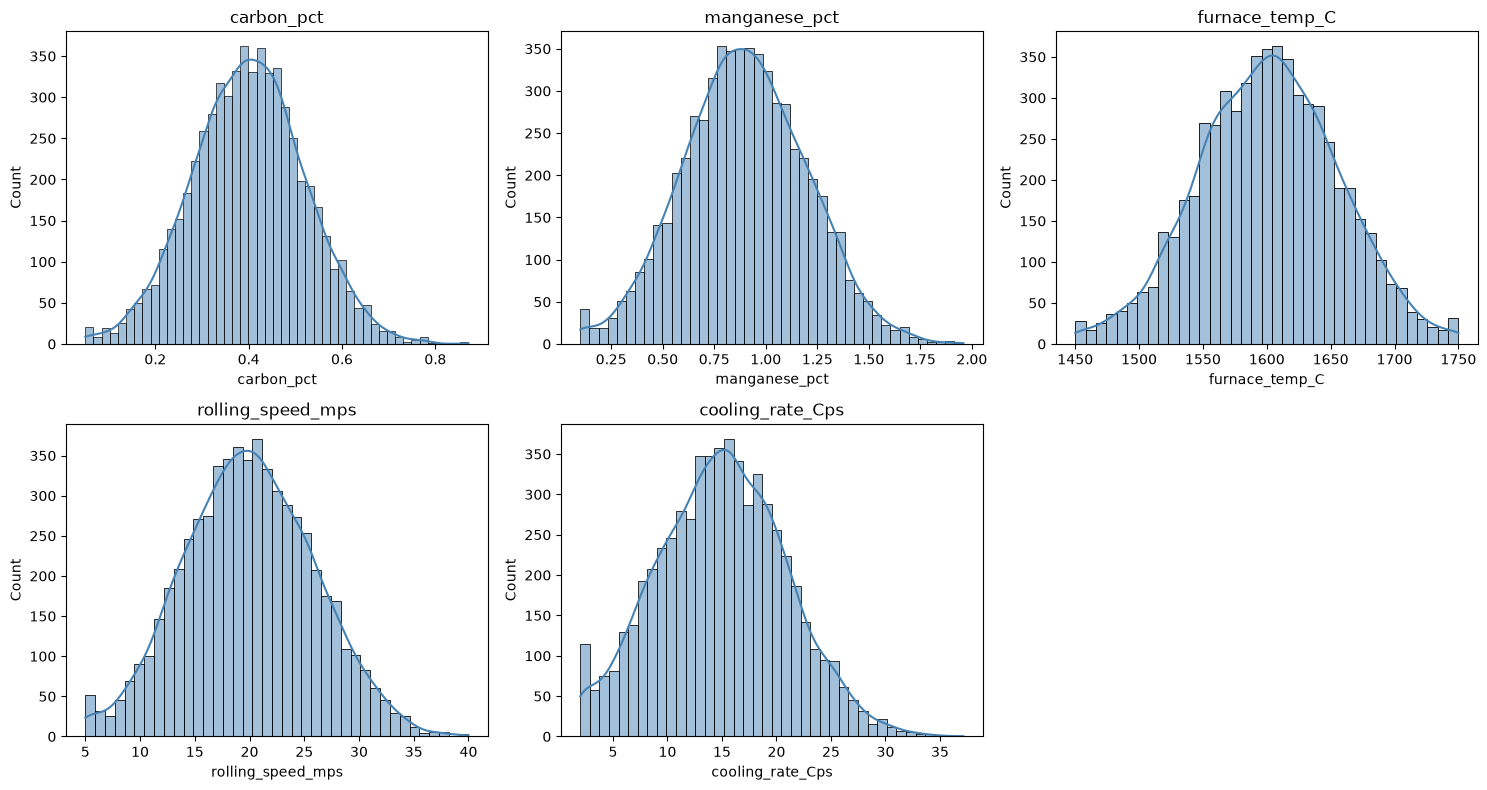

Expect: bell-shaped humps centered near carbon~0.40, mn~0.90,
        temp~1600, speed~20, cooling~15



In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, features):
    sns.histplot(df[feat], kde=True, ax=ax, color="steelblue")
    ax.set_title(feat)
axes.flat[-1].axis("off")  
plt.tight_layout()
plt.show()
plt.close()
print("Expect: bell-shaped humps centered near carbon~0.40, mn~0.90,")
print("        temp~1600, speed~20, cooling~15\n")


CHECK 3: Defect rate by binned feature (U-shape check)


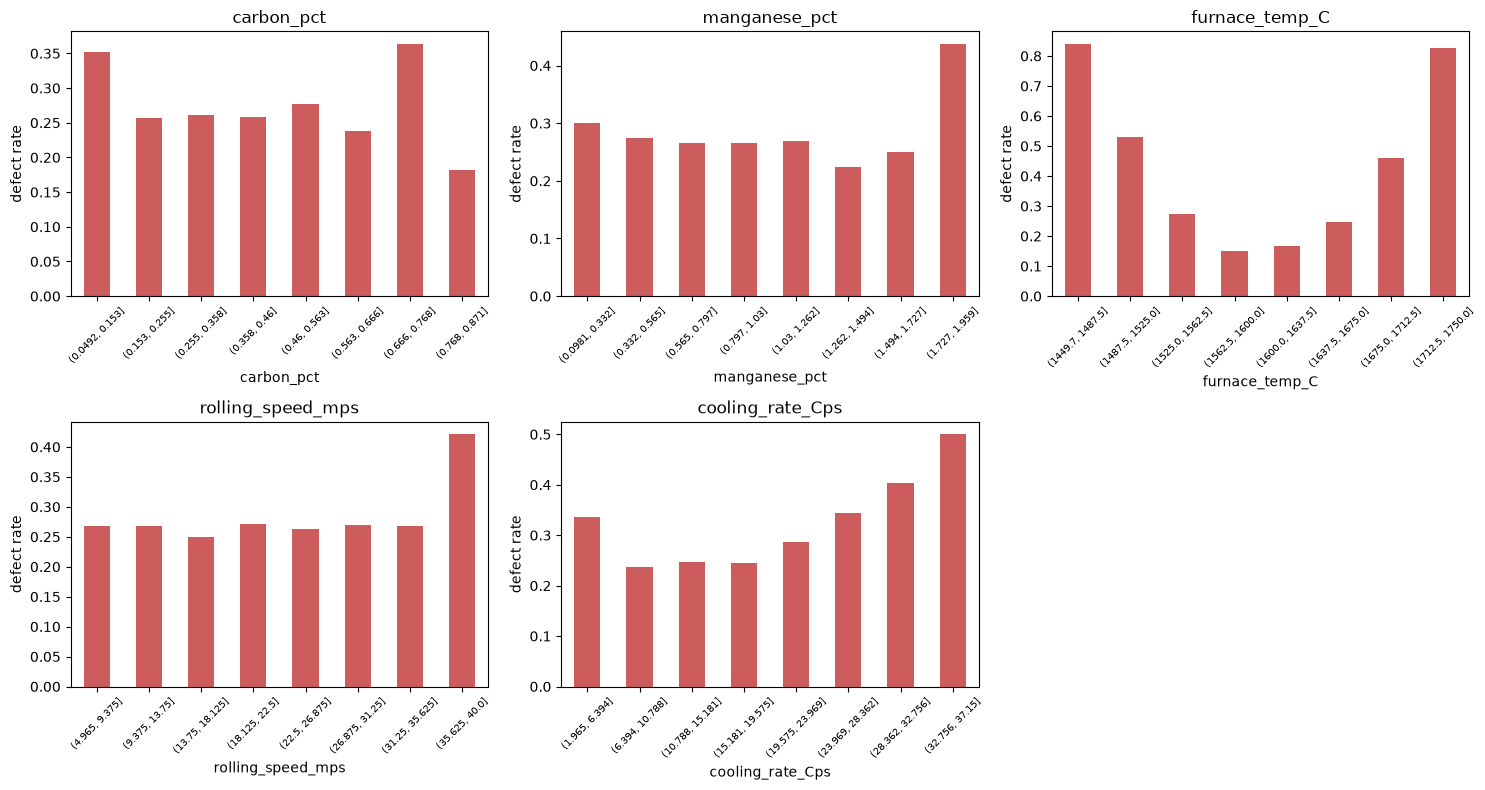

Expect:
  - carbon_pct, furnace_temp_C, cooling_rate_Cps -> U-shapes
    (low defect rate in the middle bins, high at both edges)
  - manganese_pct -> steadily DECLINING rate (not U-shaped)
  - rolling_speed_mps -> fairly FLAT on its own (its danger only
    shows up combined with temperature -- see Check 4)



In [23]:

print("CHECK 3: Defect rate by binned feature (U-shape check)")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, features):
    binned = pd.cut(df[feat], bins=8)
    rate_by_bin = df.groupby(binned, observed=True)["defect"].mean()
    rate_by_bin.plot(kind="bar", ax=ax, color="indianred")
    ax.set_title(feat)
    ax.set_ylabel("defect rate")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()
plt.close()
print("Expect:")
print("  - carbon_pct, furnace_temp_C, cooling_rate_Cps -> U-shapes")
print("    (low defect rate in the middle bins, high at both edges)")
print("  - manganese_pct -> steadily DECLINING rate (not U-shaped)")
print("  - rolling_speed_mps -> fairly FLAT on its own (its danger only")
print("    shows up combined with temperature -- see Check 4)\n")



CHECK 4: Interaction between rolling_speed and furnace_temp


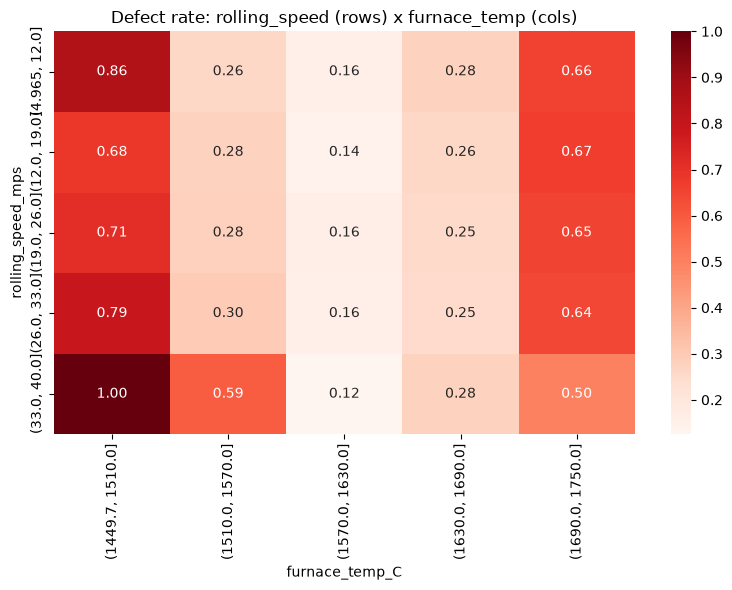

Expect: bottom-left corner (high speed + low temp) noticeably
        redder/higher than the rest of the grid



In [24]:
print("CHECK 4: Interaction between rolling_speed and furnace_temp")

speed_bins = pd.cut(df["rolling_speed_mps"], bins=5)
temp_bins = pd.cut(df["furnace_temp_C"], bins=5)
pivot = pd.pivot_table(df, values="defect", index=speed_bins, columns=temp_bins,
                        aggfunc="mean", observed=True)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds")
plt.title("Defect rate: rolling_speed (rows) x furnace_temp (cols)")
plt.tight_layout()
plt.show()
plt.close()
print("Expect: bottom-left corner (high speed + low temp) noticeably")
print("        redder/higher than the rest of the grid\n")



CHECK 5: Correlation matrix (expected to be weak)


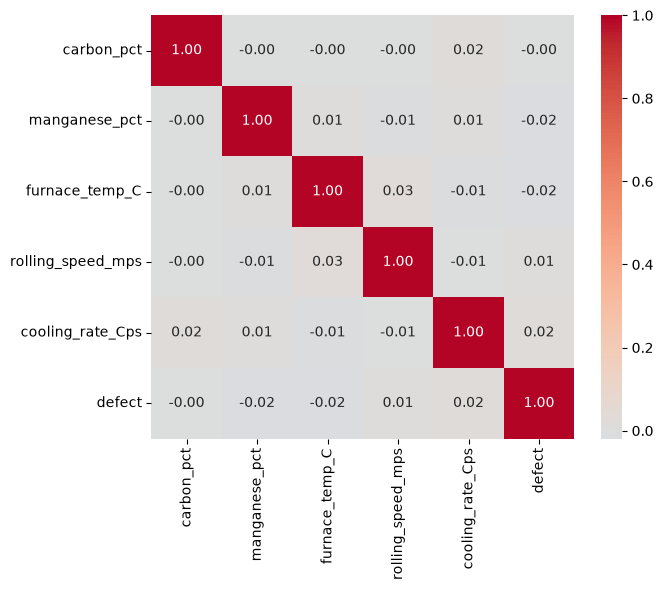

defect               1.000
cooling_rate_Cps     0.024
furnace_temp_C      -0.019
manganese_pct       -0.019
rolling_speed_mps    0.009
carbon_pct          -0.005
Name: defect, dtype: float64
Expect: all correlations with 'defect' under ~0.15 in magnitude.


In [25]:
print("CHECK 5: Correlation matrix (expected to be weak)")

corr = df[features + ["defect"]].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.tight_layout()
plt.show()
plt.close()
print(corr["defect"].sort_values(key=abs, ascending=False).round(3))
print("Expect: all correlations with 'defect' under ~0.15 in magnitude.")